<a href="https://colab.research.google.com/github/1up9059/tareas_curso_Curso_imagenes/blob/tarea2/Trabajo_Pr%C3%A1ctico_1_Filtros_lineales_y_no_lineales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
!pip install -q torch optuna opencv-python-headless wandb

In [11]:
!pip install -qU optuna wandb optuna-integration

In [12]:
import os
import wandb
os.environ["WANDB_API_KEY"] = "b4c9bd8fe58a11ee483af5b1d78d5e7b21c056ca"
wandb.login()


True

In [13]:
from optuna_integration.wandb import WeightsAndBiasesCallback as WandbCallback  # paquete nuevo
SRC = "optuna_integration.wandb"

In [14]:
print("Usando WandbCallback de:", SRC)

Usando WandbCallback de: optuna_integration.wandb


In [15]:
import cv2
import time
import optuna
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
import math

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [17]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [18]:
eye_path = "/content/drive/MyDrive/analisis_de_imagenes/Tarea_2_inputs/eye_fundus.png"
fishes_path = "/content/drive/MyDrive/analisis_de_imagenes/Tarea_2_inputs/fishes.png"
mri_path = "/content/drive/MyDrive/analisis_de_imagenes/Tarea_2_inputs/mri.png"

img_paths = {"eye": eye_path, "fishes":fishes_path, "mri":mri_path}

In [19]:
def to_numpy01(img):
  x = img.detach().float().cpu()
  # Escala por máximo local (evita saturación si hay imágenes con ruido fuerte)
  return (x / 255.0).clamp(0, 1).numpy()

def show_triplets(triplets):

    for name, triplet in triplets.items():
        keys = list(triplet.keys())  # ["original", "sp=0.01", "sp=0.05", etc.]

        # Normalización: convierte torch -> numpy y escala [0,255] -> [0,1]

        imgs = [to_numpy01(triplet[k]) for k in keys]

        # Plot
        fig, axes = plt.subplots(1, len(imgs), figsize=(5*len(imgs), 5))
        if len(imgs) == 1:
            axes = [axes]
        for ax, im, k in zip(axes, imgs, keys):
            ax.imshow(im, cmap="gray", vmin=0, vmax=1)  # fuerza escala 0–1
            ax.set_title(f"{name}: {k}")
            ax.axis("off")
        plt.tight_layout()
        plt.show()

#### Generación de ruido


In [20]:
@torch.no_grad()
def gaussian_noise(img: torch.Tensor, sigma: float):
    """img: [H,W] 0..255 float; sigma en mismos niveles (p.ej. 10 o 30)"""
    noise = torch.randn_like(img) * float(sigma)
    noisy = img + noise
    return torch.clamp(noisy, 0.0, 255.0)

def salt_and_pepper_noise(img: torch.Tensor, prob: float):
    """prob en [0,1]; reparte mitad sal y mitad pimienta"""
    r = torch.rand_like(img)
    out = img.clone()
    out[r < prob * 0.5] = 0.0      # pimienta
    out[r > 1.0 - prob * 0.5] = 255.0  # sal
    return out

def psnr(ref: torch.Tensor, test: torch.Tensor):
    ref = ref.float()
    test = test.float()
    mse = torch.mean((ref - test) ** 2)
    if mse <= 0:
        return float("inf")
    return 10.0 * math.log10((255.0 ** 2) / mse.item())

Lectura de imagenes

In [21]:
def read_images_gray(paths: dict, device=device):
    imgs = {}
    for name, p in paths.items():
        im = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
        if im is None:
            raise FileNotFoundError(f"No pude leer {p}")
        t = torch.from_numpy(im).float().to(device)
        imgs[name] = t
    return imgs

#plt.imshow(imgs_dict['mri'], cmap='gray')
#plt.axis("off")  # oculta los ejes
#plt.show()

In [22]:
imgs = read_images_gray(img_paths)
imgs_keys = list(imgs.keys())
imgs_keys

['eye', 'fishes', 'mri']

#### Aplicando ruido *Salt* and *Pepper*

Parametros:

In [23]:
SP_LOW_TRESH = 0.05
SP_HIGH_TRESH = 0.2
probs = [SP_LOW_TRESH, SP_HIGH_TRESH]

In [24]:
spn_imgs = {key: {f"prob={float(p)}": salt_and_pepper_noise(img.cpu(), float(p)) for p in probs} for key, img in imgs.items()}
sppsnr_v = {key: {f"prob={float(p)}": psnr(img.cpu(), spn_imgs[key][f"prob={float(p)}"]) for p in probs}for key, img in imgs.items()}
spkeys = list(spn_imgs[imgs_keys[0]].keys())
spkeys

['prob=0.05', 'prob=0.2']

In [25]:
sp_triplets = {"eye": {f'original': imgs[imgs_keys[0]], f'{spkeys[0]}' :spn_imgs[imgs_keys[0]][spkeys[0]], f'{spkeys[1]}':spn_imgs[imgs_keys[0]][spkeys[1]]},
            "fish":   {f'original': imgs[imgs_keys[1]], f'{spkeys[0]}' :spn_imgs[imgs_keys[1]][spkeys[0]], f'{spkeys[1]}':spn_imgs[imgs_keys[1]][spkeys[1]]},
            "mri": {f'original': imgs[imgs_keys[2]], f'{spkeys[0]}': spn_imgs[imgs_keys[2]][spkeys[0]], f'{spkeys[1]}':spn_imgs[imgs_keys[2]][spkeys[1]]}}
sp_triplets_keys = list(sp_triplets[f'{imgs_keys[0]}'].keys())
sp_triplets_keys
#plt.imshow(sp_triplets['eye'][spkeys[0]], cmap='gray')
#plt.axis("off")  # oculta los ejes
#plt.show()

['original', 'prob=0.05', 'prob=0.2']

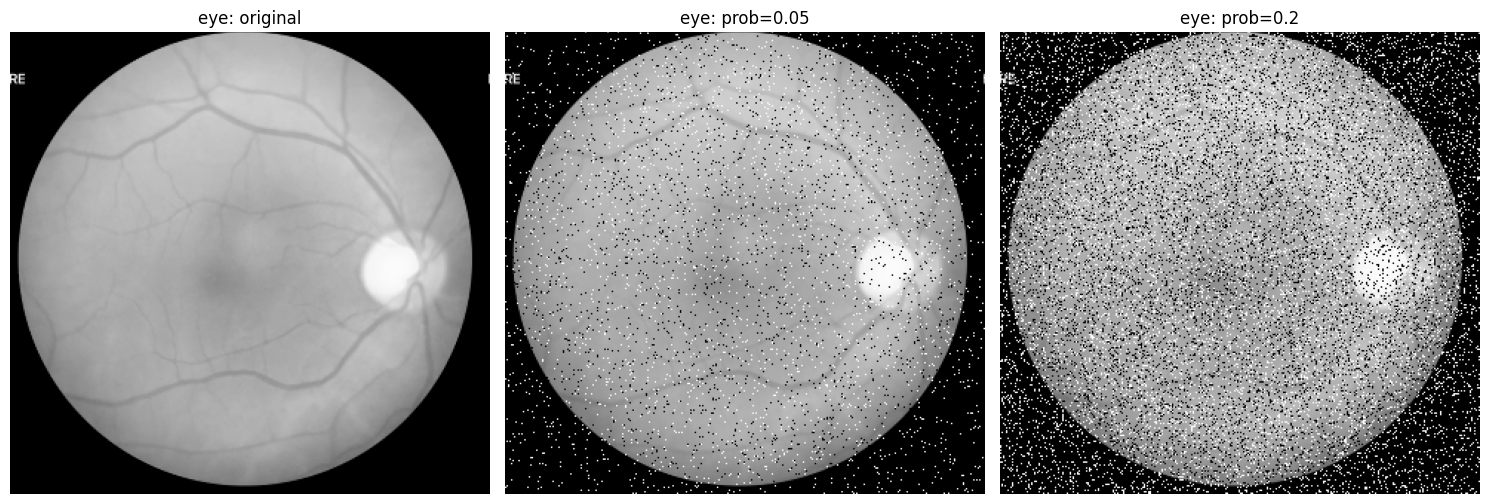

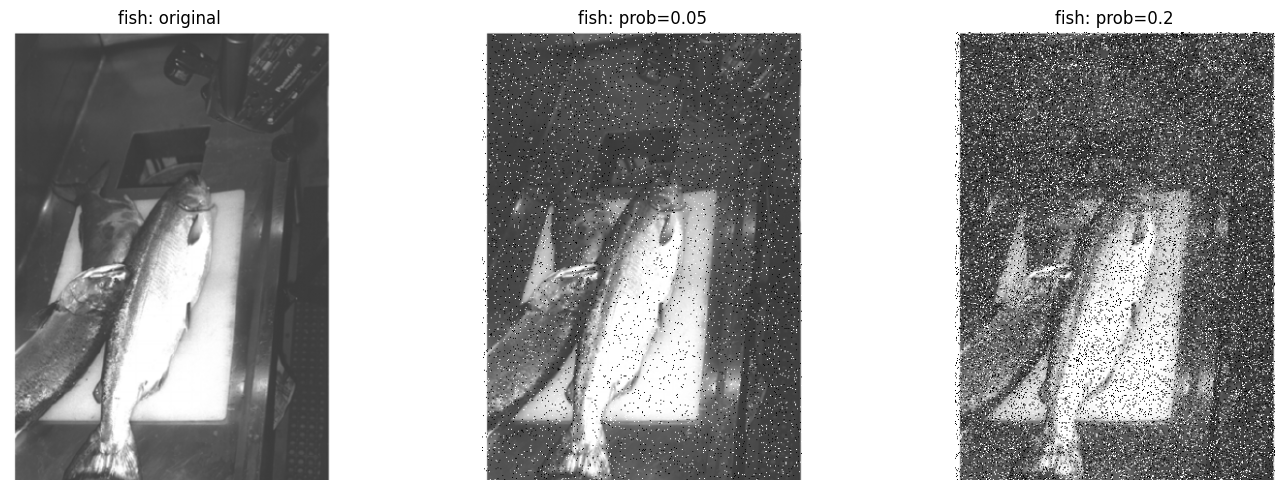

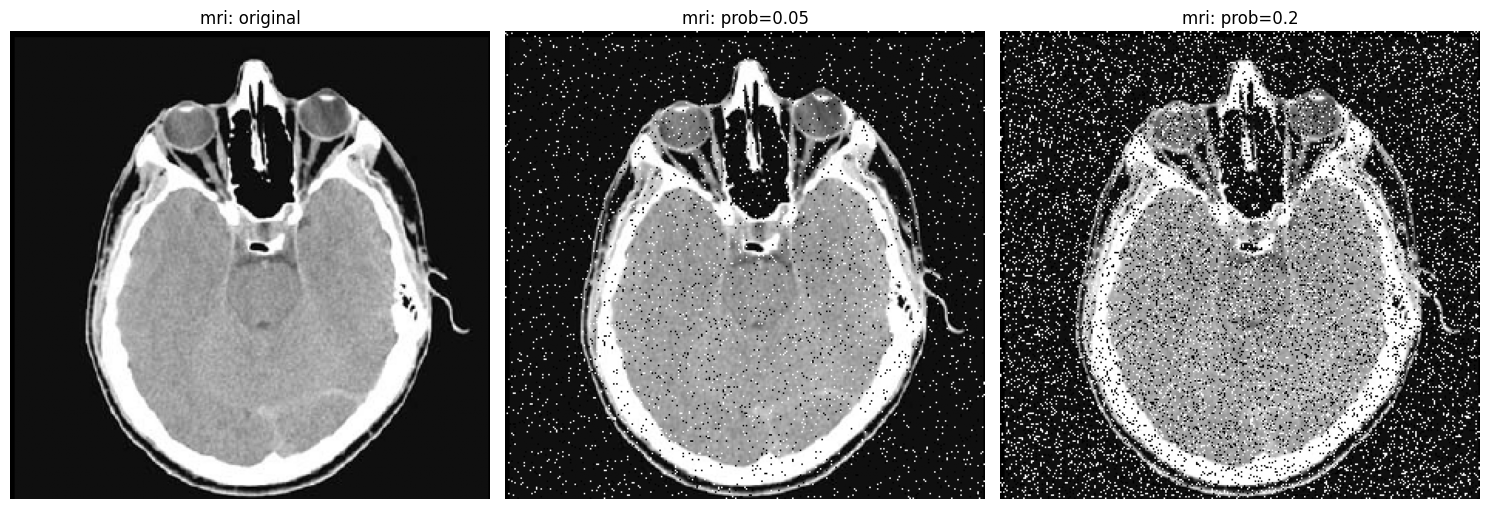

In [26]:
show_triplets(sp_triplets)

#### Aplicación de ruido *Gaussiano*

Parametros de ruido:

In [27]:
GN_LOW_TRESH = 10.0
GN_HIGH_TRESH = 30.0
sigmas = [GN_LOW_TRESH, GN_HIGH_TRESH]

In [28]:
gn_imgs = {key: {f"sigma={float(s)}": gaussian_noise(img.cpu(), s) for s in sigmas} for key, img in imgs.items()}
gpsnr_v = {key: {f"sigma={float(s)}": psnr(img.cpu(), gn_imgs[key][f"sigma={float(s)}"]) for s in sigmas} for key, img in imgs.items()}
gnkeys = list(gn_imgs[imgs_keys[0]].keys())
gnkeys

['sigma=10.0', 'sigma=30.0']

In [29]:
gn_triplets = {"eye": {"original": imgs[imgs_keys[0]], f"{gnkeys[0]}":gn_imgs[imgs_keys[0]][gnkeys[0]], f"{gnkeys[1]}": gn_imgs[imgs_keys[0]][gnkeys[1]]},
            "fish": {"original": imgs[imgs_keys[1]], f"{gnkeys[0]}": gn_imgs[imgs_keys[1]][gnkeys[0]], f"{gnkeys[1]}": gn_imgs[imgs_keys[1]][gnkeys[1]]},
            "mri": {"original": imgs[imgs_keys[2]], f"{gnkeys[0]}": gn_imgs[imgs_keys[2]][gnkeys[0]], f"{gnkeys[1]}": gn_imgs[imgs_keys[2]][gnkeys[1]]}}
gn_triplets_keys = list(gn_triplets[f'{imgs_keys[0]}'].keys())
gn_triplets_keys
#plt.imshow(gn_triplets[imgs_keys[0]][gnkeys[0]], cmap='gray')
#plt.axis("off")  # oculta los ejes
#plt.show()

['original', 'sigma=10.0', 'sigma=30.0']

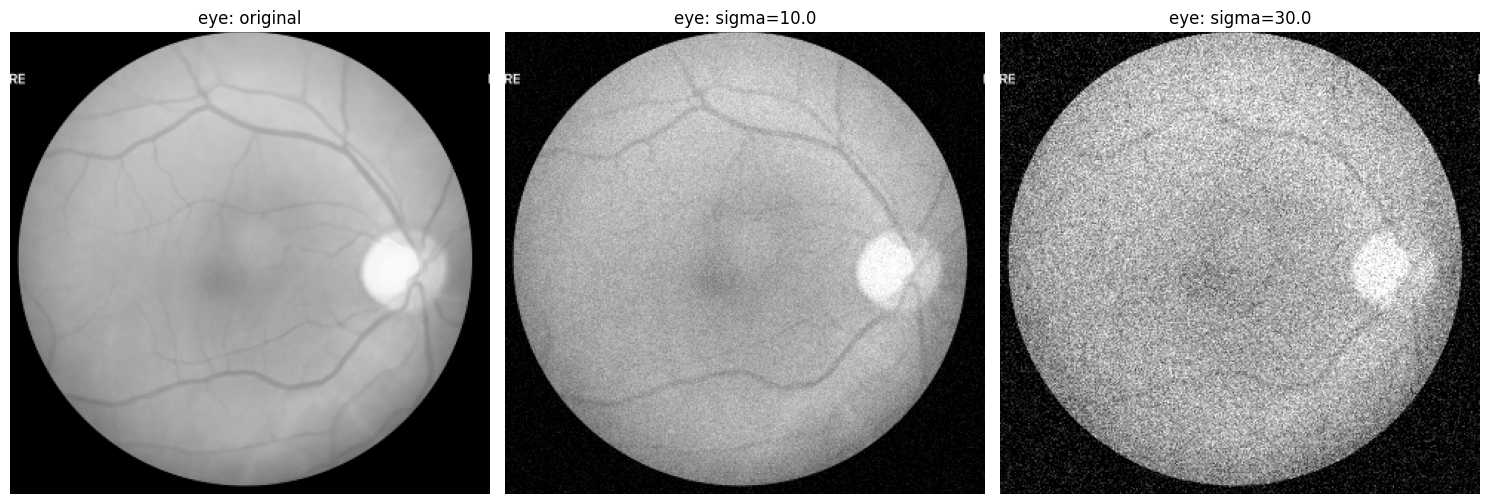

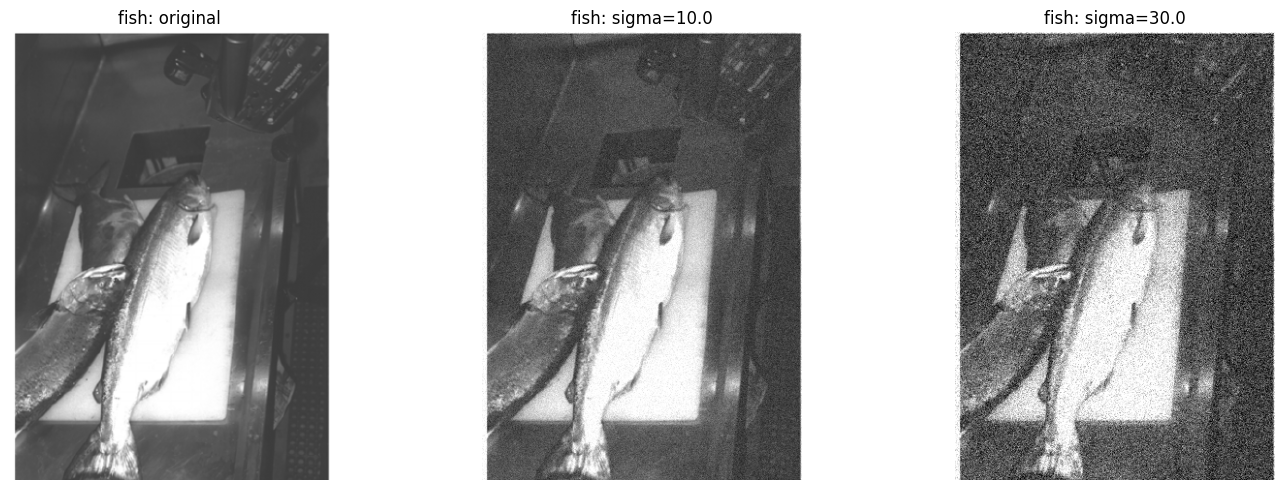

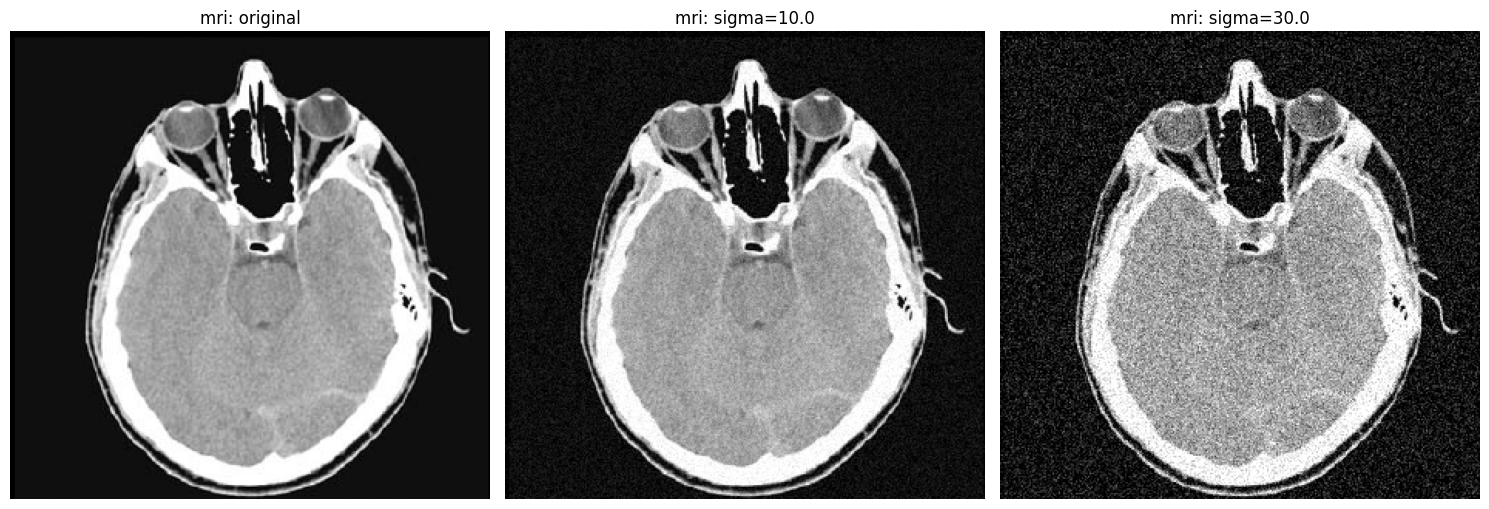

In [30]:
show_triplets(gn_triplets)

#### Run marestro de optuna:

In [31]:
wandb_run = wandb.init(
    project="TP1-Filtros-No-Lineales",
    job_type="calibracion",
    config={
        "imagenes": [f"{eye_path}", f"{fishes_path}", f"{mri_path}"],
        "filtros": ["bilateral", "nlm", "gauss_base"],
        "escenarios": ["gauss_low","gauss_high","sp_low","sp_high"],
    }
)

# 2. Filtros no lineales para eliminación de Ruido.

Para las 3 imagenes provistas con los dos escenarios de ruido Gaussiano y los dos escenarios de ruido de sal y pimienta implemente y pruebe las siguientes funciones:


1. Implemente el filtro Bilateral y el filtro de promediado No local.

   a. Para el filtro Bilateral defina la ventana de $NxN$ dimensiones con la desviación estandar espacial definida como:

   $$
   \sigma_{s} = \frac{N-1}{4}
   $$

   y reciba además la desviación estanadar en el dominio de la intensidad $\sigma_{r}$


   b. Para el filtro de promediado no local, reciba la desviación estandar en el dominio de similitud de vecidarios $\sigma_{r}$. Implemente la variante simplificada sin ventana Gaussiana

#### Fuciones utiles

In [32]:
def debug_effect(ref, out, title=""):
    ref = ref.detach().float().cpu()
    out = out.detach().float().cpu()
    diff = (out - ref).abs()
    print(f"[{title}] min/max ref:", float(ref.min()), float(ref.max()))
    print(f"[{title}] min/max out:", float(out.min()), float(out.max()))
    print(f"[{title}] mean abs diff:", float(diff.mean()))
    print(f"[{title}] max abs diff:", float(diff.max()))
    # Si quieres ver la diferencia:
    import matplotlib.pyplot as plt
    plt.figure(figsize=(12,3))
    plt.subplot(1,3,1); plt.imshow(ref/255, cmap="gray", vmin=0, vmax=1); plt.title("in"); plt.axis("off")
    plt.subplot(1,3,2); plt.imshow(out/255, cmap="gray", vmin=0, vmax=1); plt.title("out"); plt.axis("off")
    plt.subplot(1,3,3); plt.imshow(diff/ diff.max().clamp_min(1e-6), cmap="gray", vmin=0, vmax=1); plt.title("|out-in| norm"); plt.axis("off")
    plt.tight_layout(); plt.show()

### Solución a.

### implementación filtro bilateral

In [33]:
@torch.no_grad()
def bilateral_filter(img2d: torch.Tensor, N: int = 11, sigma_r: float = 25.0) -> torch.Tensor:
    """
    Filtro Bilateral vectorizado para imagen 2D en escala de grises.
    - img2d: [H, W] float en 0..255
    - N: tamaño impar de la ventana (3, 5, 7, 11, ...)
    - sigma_r: sigma del kernel de rango (en unidades de intensidad 0..255)
    - sigma_s: se fija como (N-1)/4 (según instrucciones del práctico)
    """
    assert img2d.ndim == 2, "La imagen debe ser H×W (2D)."
    N = int(N) | 1  # forzar impar
    r = N // 2
    x = img2d.to(torch.float32)
    H, W = x.shape
    device, dtype = x.device, x.dtype

    # Extraer parches: (1, K, L) con K=N*N y L=H*W
    x4 = x.unsqueeze(0).unsqueeze(0)                      # [1,1,H,W]
    patches = F.unfold(x4, kernel_size=N, padding=r)      # [1,K,L]
    K, L = patches.shape[1], patches.shape[2]

    # Centro de cada vecindario (1,1,L)
    center_idx = K // 2
    centers = patches[:, center_idx:center_idx+1, :]      # [1,1,L]

    # Kernel espacial gaussiano con sigma_s = (N-1)/4
    sigma_s = (N - 1) / 4.0
    ax = torch.arange(-r, r+1, device=device, dtype=dtype)
    yy, xx = torch.meshgrid(ax, ax, indexing='ij')
    spatial = torch.exp(-(xx**2 + yy**2) / (2.0 * (sigma_s**2) + 1e-12)).reshape(1, K, 1)  # [1,K,1]

    # Kernel de rango (intensidad)
    range_w = torch.exp(-((patches - centers) ** 2) / (2.0 * (sigma_r**2) + 1e-12))        # [1,K,L]

    # Ponderación total y normalización
    weights = spatial * range_w + 1e-12          # [1,K,L]
    num = (weights * patches).sum(dim=1, keepdim=True)  # [1,1,L]
    den = weights.sum(dim=1, keepdim=True)              # [1,1,L]
    cols = num / den                                    # [1,1,L]

    # Regresar a [H,W] y recortar a 0..255
    out = cols.view(1, 1, H, W).squeeze()
    return torch.clamp(out, 0.0, 255.0)

In [34]:
def apply_bilateral(sp_triplets: dict, N: int = 11, sigma_r: float = 25.0):
    """
    Aplica el bilateral (con σs = (N-1)/4) a TODAS las entradas NO 'original' de cada grupo.
    Mantiene 'original' sin tocar.
    Estructura esperada:
      sp_triplets = {"eye": {"original": img, "<ruido1>": img_r1, ...}, "fish": {...}, "mri": {...}}
    """
    out = {}
    for name, trip in sp_triplets.items():
        out[name] = {}
        for k, img in trip.items():
            if not isinstance(img, torch.Tensor):
                raise TypeError(f"{name}/{k} no es torch.Tensor")
            img_f = img.detach().float()
            if k.lower() == "original":
                out[name][k] = img_f
            else:
                out[name][k] = bilateral_filter(img_f, N=N, sigma_r=sigma_r)
    return out

In [35]:
print(imgs_keys)
print(sp_triplets_keys)
print(gn_triplets_keys)


['eye', 'fishes', 'mri']
['original', 'prob=0.05', 'prob=0.2']
['original', 'sigma=10.0', 'sigma=30.0']


In [36]:
bilat_sp_triplets = apply_bilateral(sp_triplets, N=11, sigma_r=25)

In [37]:
bilat_gn_triplets = apply_bilateral(gn_triplets, N=11, sigma_r=25)

In [38]:
sp_triplets_keys[2]

'prob=0.2'

[eye prob=0.2] min/max ref: 0.0 255.0
[eye prob=0.2] min/max out: 6.873899453113674e-12 255.0
[eye prob=0.2] mean abs diff: 1.446465253829956
[eye prob=0.2] max abs diff: 37.29246520996094


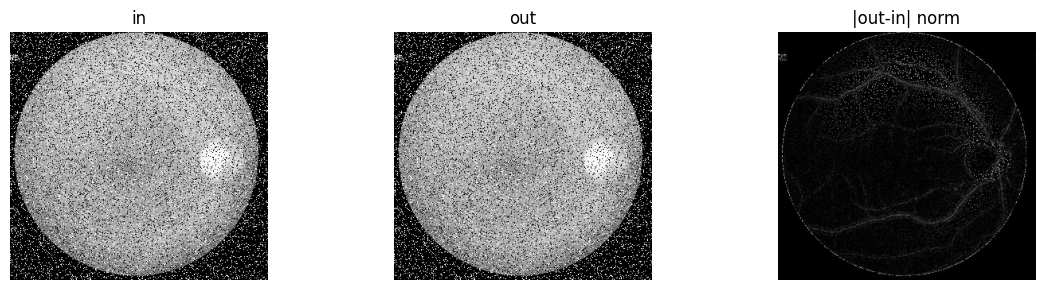

In [39]:
debug_effect(sp_triplets[imgs_keys[0]][sp_triplets_keys[2]], bilat_sp_triplets[imgs_keys[0]][sp_triplets_keys[2]], title=f"{imgs_keys[0]} {sp_triplets_keys[2]}")

[eye sigma=30.0] min/max ref: 0.0 255.0
[eye sigma=30.0] min/max out: 0.8471319675445557 250.77330017089844
[eye sigma=30.0] mean abs diff: 8.781319618225098
[eye sigma=30.0] max abs diff: 34.14468002319336


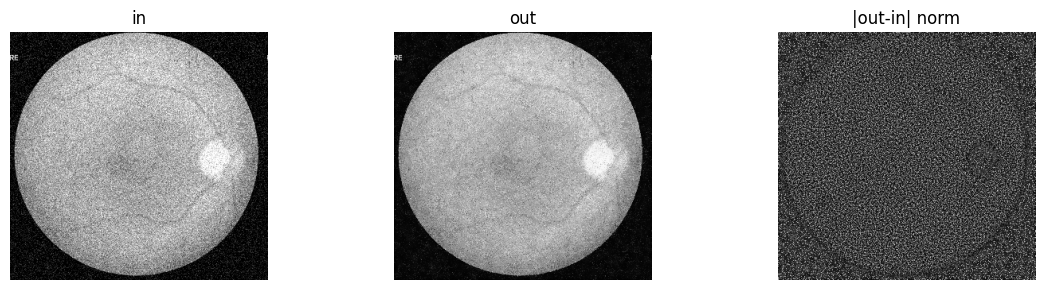

In [40]:
debug_effect(gn_triplets[imgs_keys[0]][gn_triplets_keys[2]], bilat_gn_triplets[imgs_keys[0]][gn_triplets_keys[2]], title=f"{imgs_keys[0]} {gn_triplets_keys[2]}")

2. Para el Filtro Bilateral y el de Promedio No Local:

   a. Calibre los dos parámetros en las imágenes corruptas con ruido sal y pimienta y Gaussiano por separado para los 2 escenarios. Utilice $weights$ $and$ $biases$ u $optuna$ para tal $calibracion$. Reporte los mejores valores encontrados.

   b. Filtre las imágenes usando los parámetros encontrados y reporte los resultados. Mida el PSNR de todas las imágenes, y por cada tipo de ruido reporte el PSNR promedio.

   c. Mida el tiempo de ejecución para todas las imágenes y reporte el promedio.

   d. Compare los resultados cuantitativa y cualitativamente entre el filtro bilateral, el filtro de Promediado No Local y el Gaussiano.
  